# Predicting Price Moves with News Sentiment EDA

### **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import (
    TfidfVectorizer,
    CountVectorizer,
    ENGLISH_STOP_WORDS,
)
from sklearn.decomposition import NMF
from nltk.stem import WordNetLemmatizer
from scipy.stats import zscore
import seaborn as sns
import re

### Load data set

In [2]:
df_news = pd.read_csv('../data/news_raw_data.csv')
df_news.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


#### Headline Length Statistics

In [3]:
df_news['headline_length'] = df_news['headline'].astype(str).apply(len)
df_news['headline_length'].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

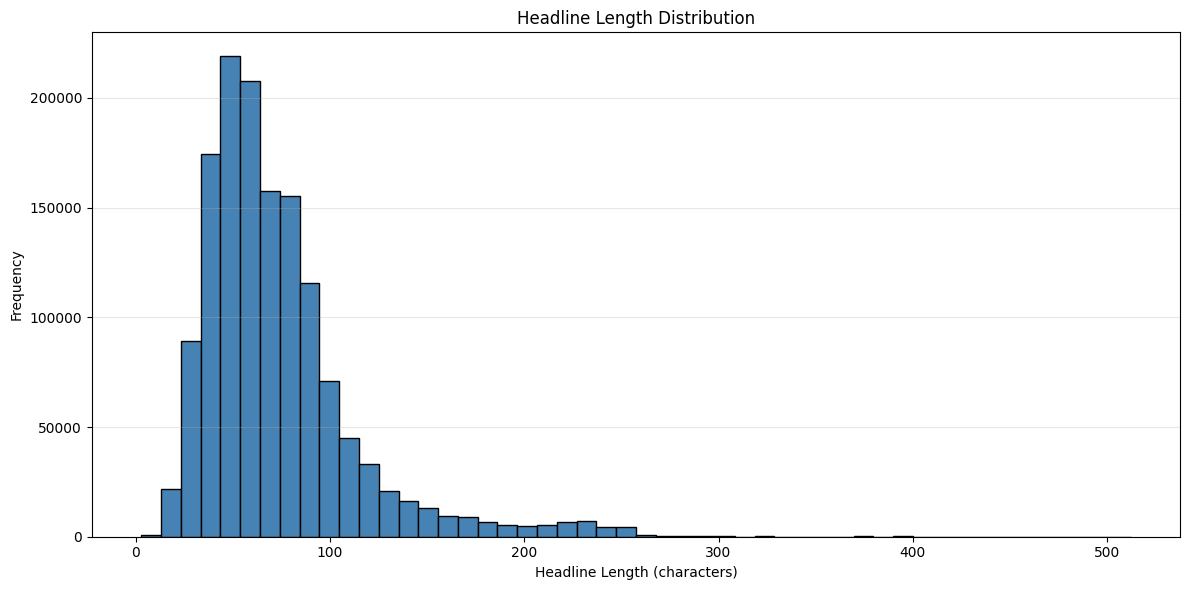

In [4]:
plt.figure(figsize=(12, 6))
plt.hist(df_news['headline_length'], bins=50, color='steelblue', edgecolor='black')
plt.xlabel('Headline Length (characters)')
plt.ylabel('Frequency')
plt.title('Headline Length Distribution')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Articles per publisher count

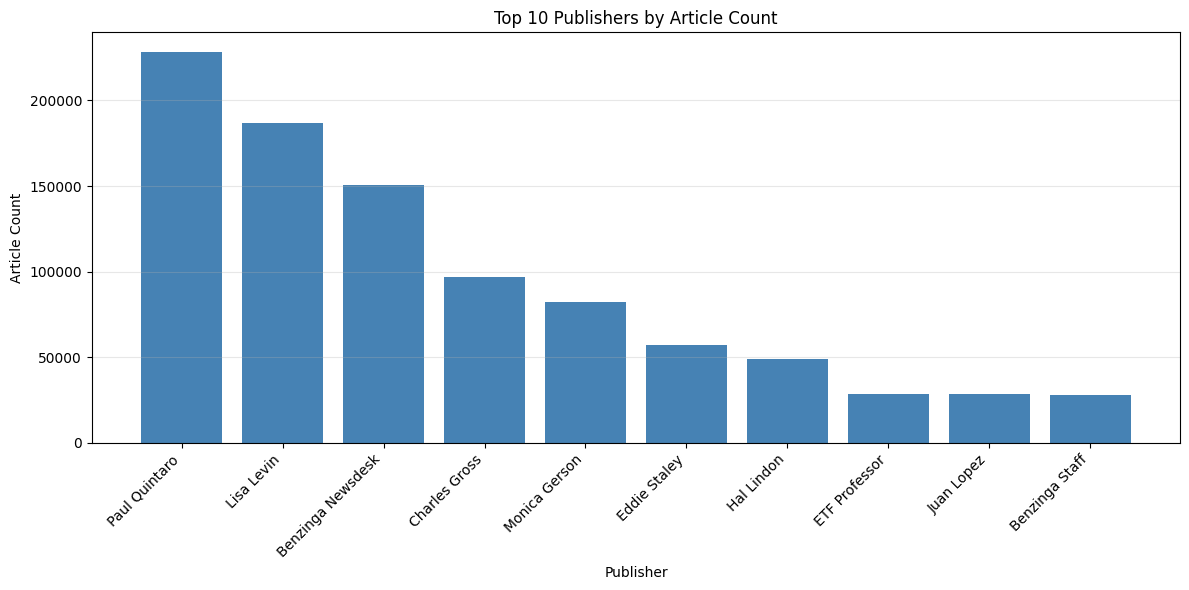

In [5]:
publisher_counts = df_news['publisher'].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(range(len(publisher_counts.head(10))), publisher_counts.head(10).values, color='steelblue')
plt.xticks(range(len(publisher_counts.head(10))), publisher_counts.head(10).index, rotation=45, ha='right')
plt.xlabel('Publisher')
plt.ylabel('Article Count')
plt.title('Top 10 Publishers by Article Count')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Publication Date Analysis

#### Convert Date Column

In [6]:
df_news['date'] = pd.to_datetime(df_news['date'], errors='coerce')
df_news.dtypes

Unnamed: 0          int64
headline           object
url                object
publisher          object
date               object
stock              object
headline_length     int64
dtype: object

In [7]:
percentages = (df_news.isna().sum()/df_news.shape[0])*100
percentages

Unnamed: 0         0.0
headline           0.0
url                0.0
publisher          0.0
date               0.0
stock              0.0
headline_length    0.0
dtype: float64

## Text Analysis (Topic Modeling)

#### Words to REMOVE (Add to Stopwords)
These words are "noise." They appear in almost every headline regardless of the topic, so they don’t help your model distinguish between an earnings report and an FDA approval.
- **words like stocks, shares, market**: In a financial dataset, these are "universal" words. They don't provide specific info because nearly every headline is about a stock or the market.
- **workds like update, announces, says**: These are functional news verbs. They don't carry sentiment or topical weight.
- **benzingas**: This is a publisher name (from Benzinga). Source names should always be removed as they are pure noise.
- **years and months**: This hold no information about the effects

In [8]:
# -----------------------------
# Clean Headlines
# -----------------------------
df_news["headline_clean"] = (
    df_news["headline"]
    .astype(str)
    .str.lower()
)

# Keep letters + numbers
df_news["headline_clean"] = df_news["headline_clean"].apply(
    lambda x: re.sub(r"[^a-zA-Z0-9\s]", "", x)
)

# Remove extra spaces
df_news["headline_clean"] = df_news["headline_clean"].apply(
    lambda x: re.sub(r"\s+", " ", x).strip()
)

In [9]:
lemmatizer = WordNetLemmatizer()

df_news["headline_clean"] = df_news["headline_clean"].apply(
    lambda x: " ".join(
        lemmatizer.lemmatize(word)
        for word in x.split()
    )
)

In [10]:
# -----------------------------
# Financial Noise Words
# -----------------------------
noise_words = [
    "stocks",
    "shares",
    "market",
    "update",
    "today",
    "daily",
    "video",
    "brief",
    "week",
    "month",
    "year",
    "52week",
    "benzingas",
    "stock",
    "session",
    "vs",
    "moving",
    "2011",
    "2012",
    "2013",
    "2014",
    "2015",
    "2016",
    "2017",
    "2018",
    "2019",
    "2020",
    "2021",
    "report"
]

stopwords = list(ENGLISH_STOP_WORDS.union(noise_words))
custom_stopwords = [lemmatizer.lemmatize(word) for word in stopwords]

In [11]:
df_news.dtypes

Unnamed: 0          int64
headline           object
url                object
publisher          object
date               object
stock              object
headline_length     int64
headline_clean     object
dtype: object

### Scan (stress test) for the best max_features to choose

In [12]:
# 1. Initialize with a high limit to see the full "long tail" of words
test_tfidf = TfidfVectorizer(
    max_features=1000, 
    stop_words=list(custom_stopwords), 
    ngram_range=(1, 2)
)

# 2. Fit and transform your cleaned headlines
tfidf_matrix = test_tfidf.fit_transform(df_news['headline_clean'].fillna(''))

# 3. Calculate the average TF-IDF score for every word
# This measures how "important" each word is across the whole dataset
feature_scores = tfidf_matrix.mean(axis=0).A1
sorted_scores = np.sort(feature_scores)[::-1] # Sort highest to lowest

### Plot (The Elbow Method)

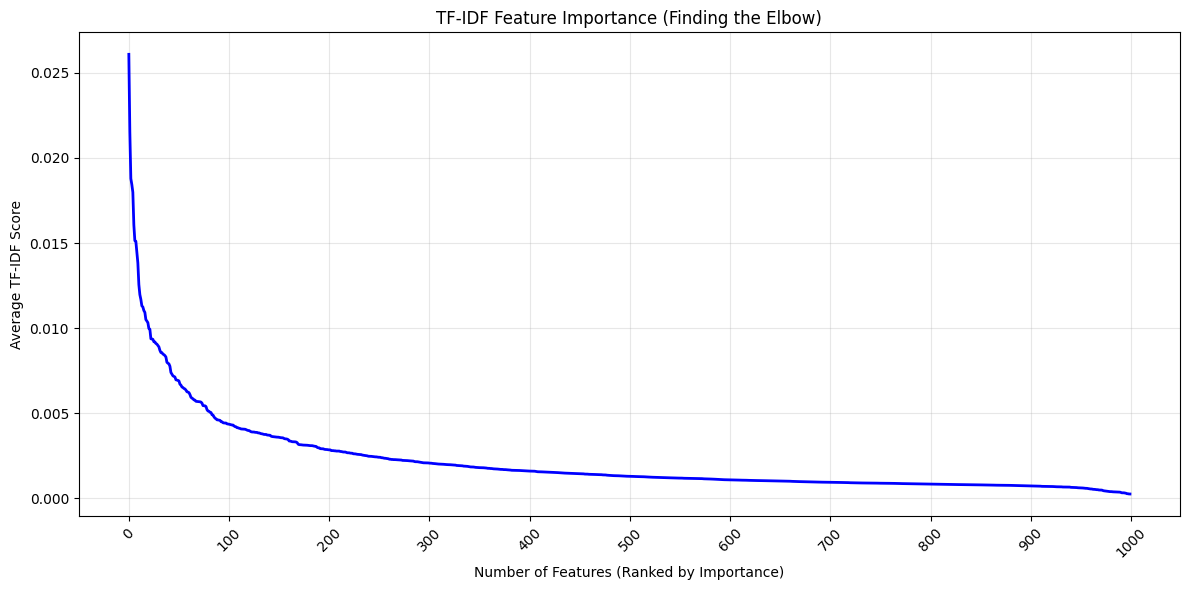

In [13]:
plt.figure(figsize=(12, 6)) # Slightly wider to fit more labels
plt.plot(range(len(sorted_scores)), sorted_scores, linewidth=2, color='blue')

# Create a range from 0 to the end of your scores with a step of 100
plt.xticks(np.arange(0, len(sorted_scores) + 1, 100), rotation=45) 

# Formatting the chart
plt.title("TF-IDF Feature Importance (Finding the Elbow)")
plt.xlabel("Number of Features (Ranked by Importance)")
plt.ylabel("Average TF-IDF Score")
plt.grid(True, alpha=0.3)

plt.tight_layout() # Prevents labels from being cut off
plt.show()

In [14]:
MAX_FEATURES = 100

In [15]:
def tfidf(stop_words='english'):
    tfidf = TfidfVectorizer(
        max_features=MAX_FEATURES, stop_words=stop_words, ngram_range=(1, 2), min_df=3
    )

    tfidf_matrix = tfidf.fit_transform(df_news["headline_clean"].fillna(""))

    feature_names = tfidf.get_feature_names_out()

    # Average TF-IDF Scores
    tfidf_scores = tfidf_matrix.mean(axis=0).A1

    top_keywords = sorted(
        zip(feature_names, tfidf_scores), key=lambda x: x[1], reverse=True
    )
    
    print("Top 20 Keywords/Phrases:")

    for i, (keyword, score) in enumerate(top_keywords[:20], 1):
        print(f"{i}. {keyword}: {score:.4f}")

    # -----------------------------
    # Visualization
    # -----------------------------
    top_k = dict(top_keywords[:15])

    plt.figure(figsize=(12, 6))
    plt.barh(list(top_k.keys()), list(top_k.values()))

    plt.xlabel("TF-IDF Score")
    plt.title("Top 15 Financial News Keywords/Phrases")

    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.show()

### Before removing custome stopwords

Top 20 Keywords/Phrases:
1. stock: 0.0595
2. market: 0.0429
3. report: 0.0421
4. share: 0.0392
5. est: 0.0346
6. earnings: 0.0337
7. update: 0.0319
8. eps: 0.0304
9. announces: 0.0291
10. benzingas: 0.0263
11. sale: 0.0257
12. downgrade: 0.0253
13. buy: 0.0251
14. etf: 0.0246
15. say: 0.0228
16. price: 0.0223
17. upgrade: 0.0222
18. pt: 0.0221
19. lower: 0.0211
20. company: 0.0201


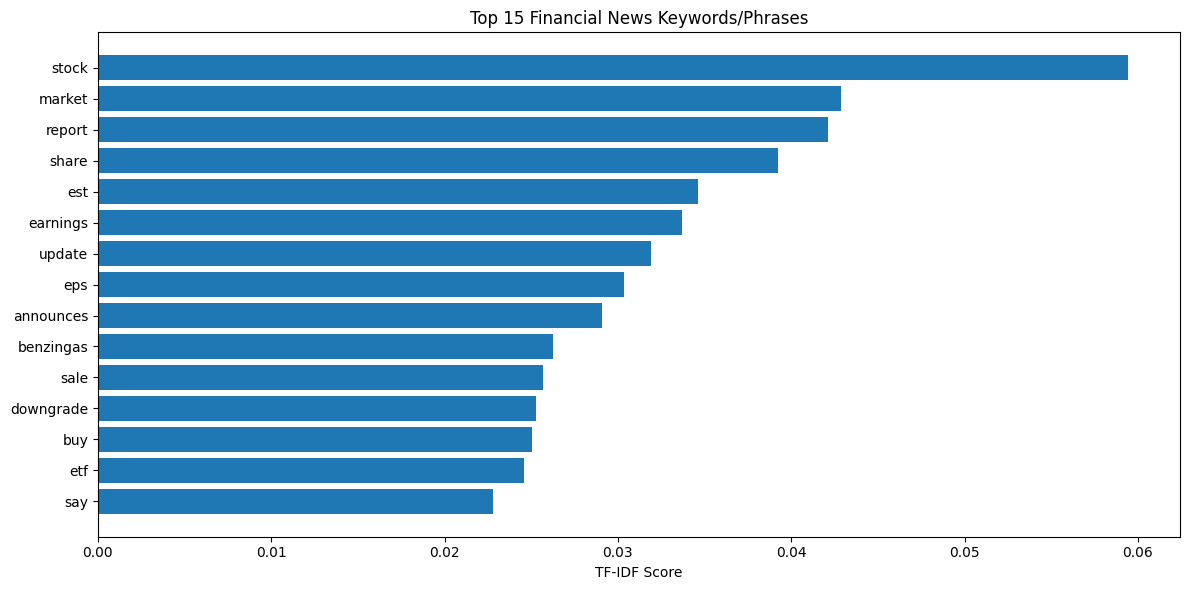

In [16]:
tfidf()

### After Removing custome stopwords

Top 20 Keywords/Phrases:
1. earnings: 0.0358
2. est: 0.0337
3. eps: 0.0297
4. announces: 0.0295
5. downgrade: 0.0294
6. upgrade: 0.0271
7. buy: 0.0256
8. sale: 0.0255
9. etf: 0.0250
10. say: 0.0238
11. price: 0.0221
12. pt: 0.0212
13. lower: 0.0210
14. new: 0.0204
15. company: 0.0202
16. premarket: 0.0202
17. trading: 0.0197
18. higher: 0.0190
19. raise: 0.0189
20. industry: 0.0180


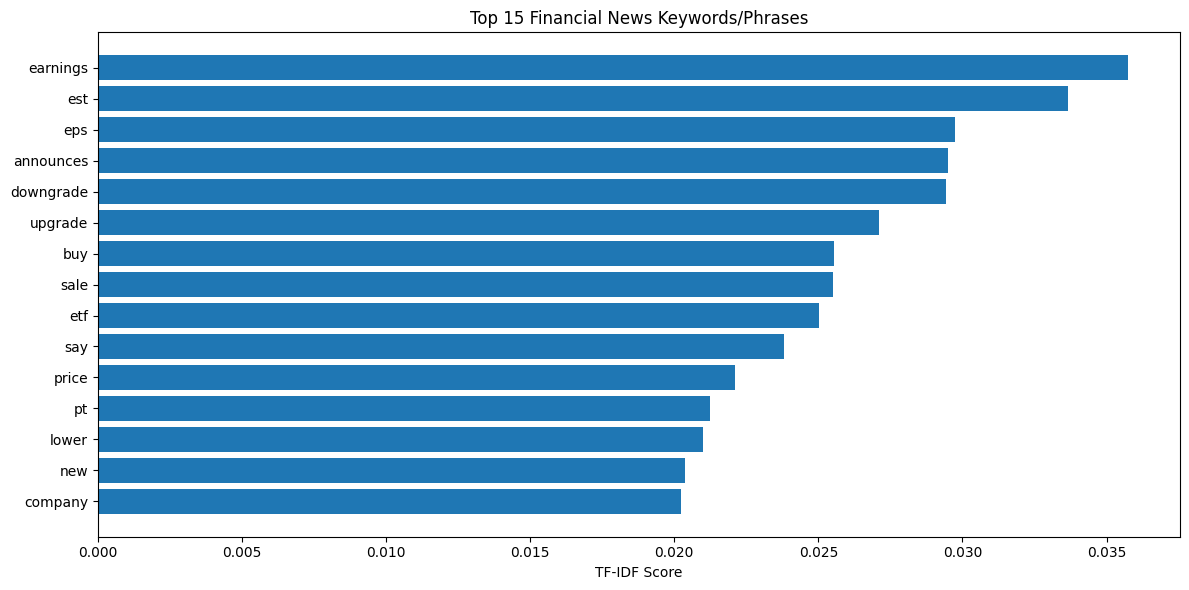

In [17]:
tfidf(stop_words=list(custom_stopwords))

## Significant topics or recurring themes

In [18]:
# ====================================================================
# PREPARATION: Vectorization and NMF Fitting
# ====================================================================

# We use TF-IDF for NMF as it yields much cleaner topics than raw counts
tfidf_vec = TfidfVectorizer(
    max_features=MAX_FEATURES,  # Based on your elbow plot
    stop_words=list(custom_stopwords),
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf_vec.fit_transform(df_news["headline_clean"].fillna(""))
feature_names = tfidf_vec.get_feature_names_out()

# Initialize and fit NMF
n_topics = 5 
nmf_model = NMF(n_components=n_topics, random_state=42, init='nndsvd')
nmf_model.fit(tfidf_matrix)

# ====================================================================
# TOPIC EXTRACTION: Identifying Significant Topics
# ====================================================================

print("=" * 80)
print("RECURRING THEMES & SIGNIFICANT TOPICS (NMF Analysis)")
print("=" * 80)

n_words_per_topic = 10
topics_summary = []

for topic_idx, topic_weights in enumerate(nmf_model.components_):
    # Get indices of top words
    top_indices = topic_weights.argsort()[-n_words_per_topic:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    
    print(f"\n--- Topic {topic_idx + 1} ---")
    print(", ".join(top_words))
    topics_summary.append(top_words)

# ====================================================================
# TOPIC PREVALENCE
# ====================================================================
print("\n" + "=" * 80)
print("TOPIC PREVALENCE (Headline Distribution)")
print("=" * 80)

doc_topic_dist = nmf_model.transform(tfidf_matrix)
dominant_topics = doc_topic_dist.argmax(axis=1)

topic_counts = pd.Series(dominant_topics).value_counts().sort_index()
for topic_idx, count in topic_counts.items():
    percentage = (count / len(df_news) * 100)
    print(f"Topic {topic_idx + 1}: {count:>7d} articles ({percentage:>5.2f}%)")

# ====================================================================
# RECURRING PHRASES (Bigrams)
# ====================================================================
print("\n" + "=" * 80)
print("RECURRING PHRASES (Most Common 2-grams)")
print("=" * 80)

# Use CountVectorizer here because for "recurring phrases" we want pure frequency
bigram_vec = CountVectorizer(
    stop_words=list(custom_stopwords),
    ngram_range=(2, 2),
    min_df=5
)

bigram_matrix = bigram_vec.fit_transform(df_news["headline_clean"].fillna(""))
bigram_names = bigram_vec.get_feature_names_out()
phrase_freq = bigram_matrix.sum(axis=0).A1

# Sort and get top 15
top_phrase_indices = phrase_freq.argsort()[-15:][::-1]

for i, idx in enumerate(top_phrase_indices, 1):
    print(f"{i:>2d}. {bigram_names[idx]:30s} ({int(phrase_freq[idx]):>6d} occurrences)")

# ====================================================================
# FINANCIAL NEWS THEME SUMMARY (Dynamic Table)
# ====================================================================
# Instead of hardcoding, we use the actual top 3 words from NMF
themes_df = pd.DataFrame({
    'Topic': [f"Topic {i+1}" for i in range(n_topics)],
    'Identified Theme': ['TBD', 'TBD', 'TBD', 'TBD', 'TBD'], # You will fill these after seeing the output
    'Top Indicators': [", ".join(words[:5]) for words in topics_summary]
})

print("\n" + "=" * 80)
print("THEME SUMMARY TABLE (Initial Mapping)")
print("=" * 80)
print(themes_df.to_string(index=False))

RECURRING THEMES & SIGNIFICANT TOPICS (NMF Analysis)

--- Topic 1 ---
est, eps, sale, revenue, q4, q2, q1, q3, est revenue, estimate

--- Topic 2 ---
announces, price, buy, target, pt, maintains, price target, raise, lower, initiate

--- Topic 3 ---
earnings, scheduled, earnings scheduled, option, alert, option alert, higher, beat, analyst, following

--- Topic 4 ---
downgrade, upgrade, neutral, hold, buy, bank, pt, outperform, capital, morgan

--- Topic 5 ---
etf, watch, new, benzinga, midday, sector, high, energy, 10, low

TOPIC PREVALENCE (Headline Distribution)
Topic 1:  473976 articles (33.68%)
Topic 2:  415087 articles (29.49%)
Topic 3:  113731 articles ( 8.08%)
Topic 4:  101283 articles ( 7.20%)
Topic 5:  303251 articles (21.55%)

RECURRING PHRASES (Most Common 2-grams)
 1. price target                   ( 47710 occurrences)
 2. earnings scheduled             ( 32062 occurrences)
 3. initiate coverage              ( 29041 occurrences)
 4. raise pt                       ( 27232 o

## **Time Series Analysis of News Volume**

In [19]:
major_events = {
    "2020-03": "COVID-19 Market Crash",
    "2020-11": "US Election",
    "2022-02": "Russia-Ukraine Conflict",
    "2022-11": "US Midterm Elections",
    "2023-01": "Crypto Market Crash",   
    "2023-09": "Fed Interest Rate Hike"
}

### PREPARATION: Aggregate Data by Day

In [20]:
# Ensure the 'date' column is in datetime format and drop any rows where it's invalid
df_news['date'] = pd.to_datetime(df_news['date'], errors='coerce', utc=True)
df_news.dtypes

Unnamed: 0                       int64
headline                        object
url                             object
publisher                       object
date               datetime64[ns, UTC]
stock                           object
headline_length                  int64
headline_clean                  object
dtype: object

In [21]:
# Remove timezone information to prevent mixing tz-aware and tz-naive datetimes
if df_news['date'].dt.tz is not None:
    df_news['date'] = df_news['date'].dt.tz_localize(None)

print("Data types in df_news:")
print(df_news.dtypes)
print("Date range in df_news:")

_before = df_news['date'].count()
date_series = df_news["date"].dropna()
_after = date_series.count()

print(f"Removed {_before - _after} rows with invalid dates. Remaining valid dates: {_after}")
print(f"Null values in 'date' column: {df_news['date'].isna().sum()}")

Data types in df_news:
Unnamed: 0                  int64
headline                   object
url                        object
publisher                  object
date               datetime64[ns]
stock                      object
headline_length             int64
headline_clean             object
dtype: object
Date range in df_news:
Removed 0 rows with invalid dates. Remaining valid dates: 1407328
Null values in 'date' column: 0


In [22]:
print(df_news["date"].dtype)

datetime64[ns]


### Plot Daily News Volume

Detected News Spikes:
     publication_day  article_count   z_score
36        2009-08-10           1130  2.750159
674       2011-05-23            930  2.039675
740       2011-07-28           1044  2.444651
2558      2016-08-04            943  2.085857
2642      2016-10-27            931  2.043228
...              ...            ...       ...
3919      2020-05-07           1398  3.702208
3920      2020-05-08            927  2.029018
3925      2020-05-13           1005  2.306107
3938      2020-05-26            967  2.171115
3948      2020-06-05            932  2.046780

[85 rows x 3 columns]


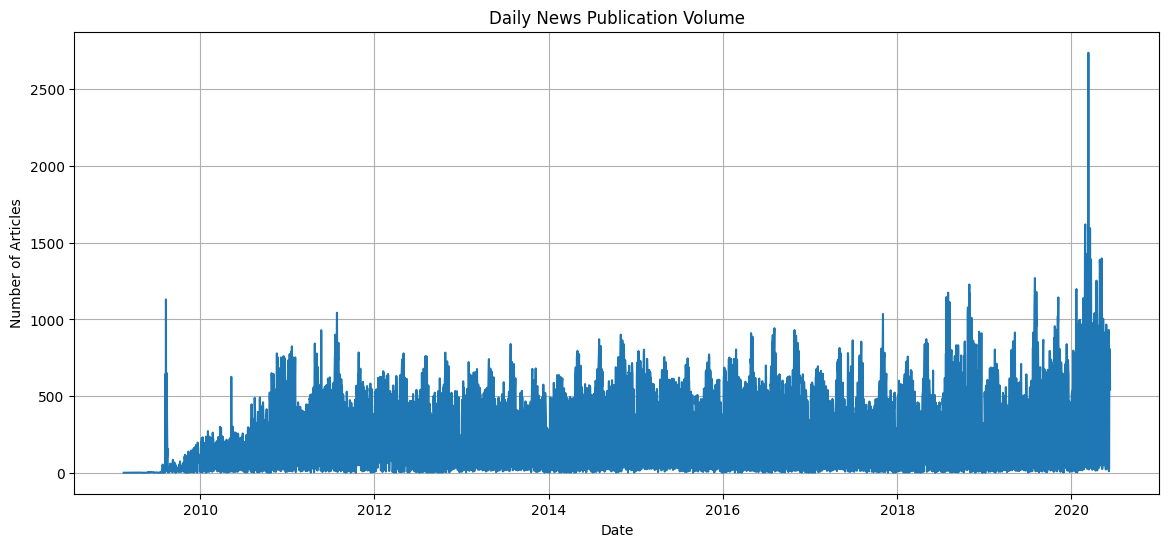

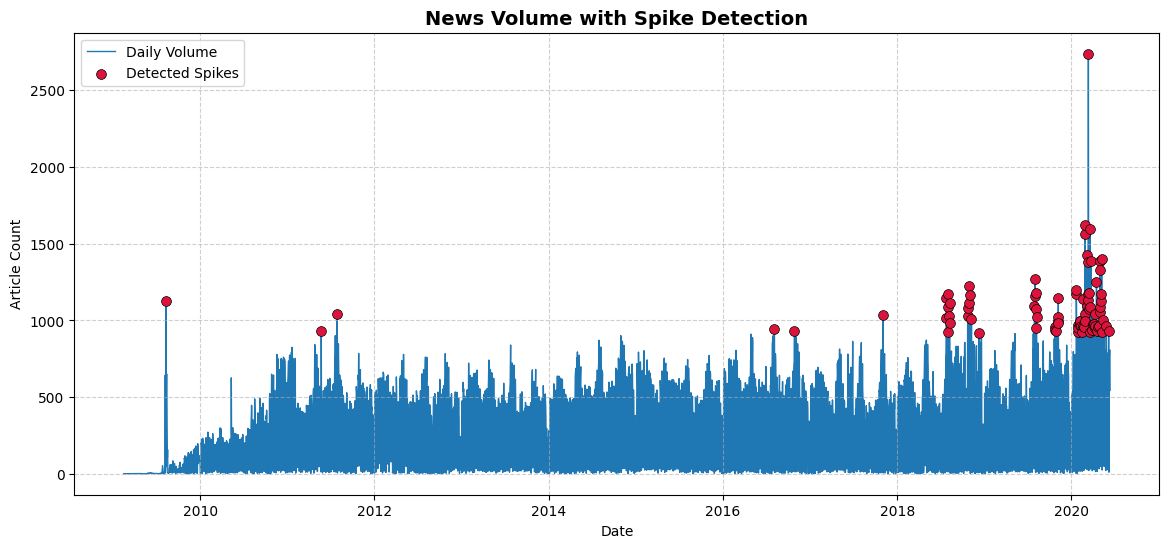


Spikes around major market events:


,Event,Event Date,Window Start,Window End,Peak Day,Peak Articles,30D Baseline Avg,Peak vs Baseline Z,Spike Detected
0,COVID-19 Market Crash,2020-03-01,2020-02-23,2020-03-08,2020-02-28,1620,656.7,2.0,False


In [23]:
from IPython.display import display

# =========================
# Extract Date 
# =========================
df_news["publication_day"] = (
    df_news["date"].dt.date
)
# =========================
# Daily News Volume
# =========================
daily_news_volume = (
    df_news.groupby("publication_day")
    .size()
)

# Convert to DataFrame
daily_news_volume = (
    daily_news_volume
    .reset_index(name="article_count")
)

# =========================
# Compute Z-Scores
# =========================
daily_news_volume["z_score"] = zscore(
    daily_news_volume["article_count"]
)

# =========================
# Detect Significant Spikes
# =========================
news_spikes = daily_news_volume[
    daily_news_volume["z_score"] > 2
]

print("Detected News Spikes:")
print(news_spikes)

# =========================
# Plot Daily News Volume
# =========================
plt.figure(figsize=(14,6))

plt.plot(
    daily_news_volume["publication_day"],
    daily_news_volume["article_count"]
)

plt.title("Daily News Publication Volume")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.grid(True)

plt.show()

# =========================
# Highlight Spikes
# =========================
plt.figure(figsize=(14,6))


plt.plot(
    daily_news_volume["publication_day"], 
    daily_news_volume["article_count"], 
    linewidth=1, 
    label="Daily Volume",
    zorder=1                    
)

plt.scatter(
    news_spikes["publication_day"], 
    news_spikes["article_count"], 
    color='crimson',            
    s=50,                      
    label="Detected Spikes",
    edgecolor='black',          
    linewidth=0.5,
    zorder=2                   
)

plt.title("News Volume with Spike Detection", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Article Count")

plt.grid(True, linestyle='--', alpha=0.6) 
plt.legend()

plt.show()

# Prepare a date-indexed copy for event analysis
event_volume = daily_news_volume.copy()
event_volume["publication_day"] = pd.to_datetime(event_volume["publication_day"])
event_volume = event_volume.set_index("publication_day").sort_index()

event_spike_rows = []

for event_key, event_name in major_events.items():
    event_date = pd.to_datetime(f"{event_key}-01")
    window_start = event_date - pd.Timedelta(days=7)
    window_end = event_date + pd.Timedelta(days=7)

    window_df = event_volume.loc[window_start:window_end]
    if window_df.empty:
        continue

    peak_day = window_df["article_count"].idxmax()
    peak_articles = int(window_df.loc[peak_day, "article_count"])

    baseline_df = event_volume.loc[event_date - pd.Timedelta(days=30): event_date - pd.Timedelta(days=1)]
    baseline_mean = baseline_df["article_count"].mean()
    baseline_std = baseline_df["article_count"].std(ddof=0)

    peak_z = np.nan
    if pd.notna(baseline_std) and baseline_std > 0:
        peak_z = (peak_articles - baseline_mean) / baseline_std

    event_spike_rows.append({
        "Event": event_name,
        "Event Date": event_date.date(),
        "Window Start": window_start.date(),
        "Window End": window_end.date(),
        "Peak Day": peak_day.date(),
        "Peak Articles": peak_articles,
        "30D Baseline Avg": round(baseline_mean, 1) if pd.notna(baseline_mean) else np.nan,
        "Peak vs Baseline Z": round(peak_z, 2) if pd.notna(peak_z) else np.nan,
        "Spike Detected": bool(pd.notna(peak_z) and peak_z > 2)
    })

event_spike_df = pd.DataFrame(event_spike_rows)

print("\nSpikes around major market events:")
display(event_spike_df)




### Analyze publishing times

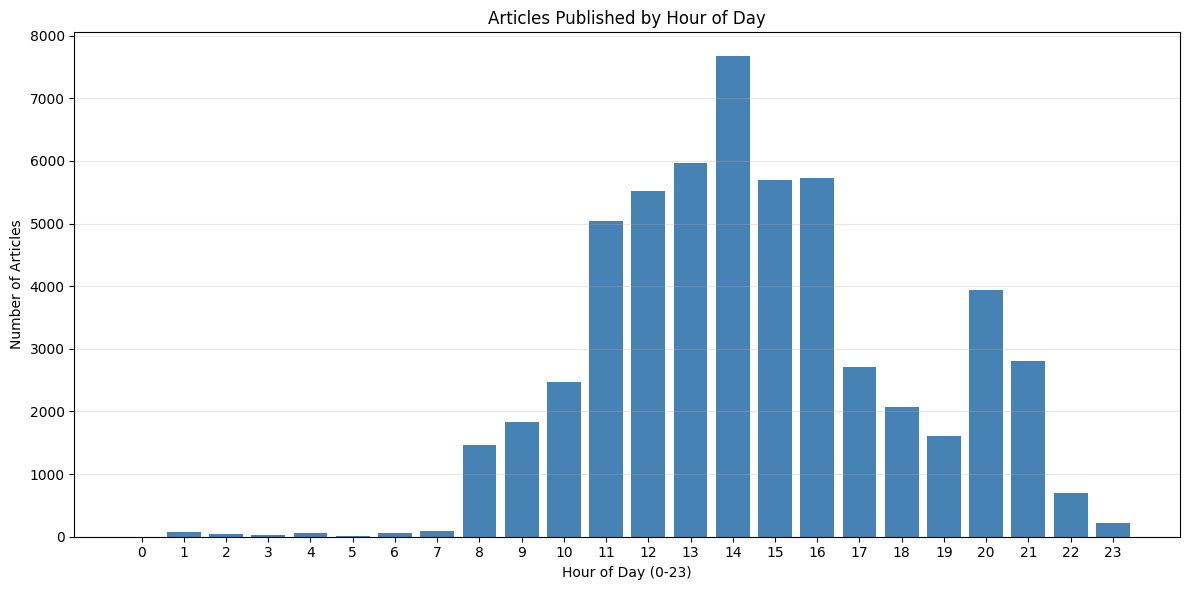

The hour with the greatest number of articles is 14:00, with 7,669 articles published.


In [24]:
df_news["publication_hour"] = (
    df_news["date"].dt.hour
)

hourly_counts = (
    df_news["publication_hour"]
    .value_counts()
    .sort_index()
)
hourly_counts
# Set the zero index count to 0
hourly_counts.iloc[0] = 0

# Create a bar graph
plt.figure(figsize=(12, 6))
plt.bar(hourly_counts.index, hourly_counts.values, color='steelblue')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Articles')
plt.title('Articles Published by Hour of Day')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

peak_hour = hourly_counts.idxmax()
peak_count = hourly_counts.max()

print(f"The hour with the greatest number of articles is {peak_hour}:00, with {peak_count:,} articles published.")

## **Publisher Analysis**

In [25]:
publisher_series = df_news["publisher"].astype(str).str.strip()
email_mask = publisher_series.str.contains("@", na=False)

# Extract organization/domain for email-based publisher names
publisher_org = publisher_series.where(~email_mask, publisher_series.str.extract(r"@([^>\s]+)$", expand=False).fillna(publisher_series))
publisher_org = publisher_org.str.lower()

publisher_activity = publisher_org.value_counts()

print("Top 20 most active publishers / organizations:")

# --- FIX: Move the index to a column so the headers align side-by-side ---
publisher_df = publisher_activity.head(20).reset_index()
publisher_df.columns = ["Publisher", "Article Count"]

display(publisher_df)

Top 20 most active publishers / organizations:


,Publisher,Article Count
0,paul quintaro,228373
1,lisa levin,186979
2,benzinga newsdesk,150484
3,charles gross,96732
4,monica gerson,82380
5,eddie staley,57254
6,hal lindon,49047
7,etf professor,28489
8,juan lopez,28438
9,benzinga staff,28114


### Analyze email domains separately

In [26]:
email_domains = (
    publisher_series[email_mask]
    .str.extract(r"@([^>\s]+)$", expand=False)
    .str.lower()
)

if not email_domains.empty:
    domain_counts = email_domains.value_counts()
    print("\nTop 20 email domains (organizational contribution patterns):")
    domain_df = domain_counts.head(20).reset_index()
    domain_df.columns = ["Publisher Organization Domain", "Article Count"]

    display(domain_df)
else:
    print("\nNo email-style publisher names found.")


Top 20 email domains (organizational contribution patterns):


,Publisher Organization Domain,Article Count
0,benzinga.com,7937
1,gmail.com,139
2,andyswan.com,5
3,investdiva.com,2
4,tothetick.com,2
5,eosdetroit.io,1
6,forextraininggroup.com,1
7,stockmetrix.net,1


### Characterize coverage by dominant topic

In [27]:
topic_matrix = doc_topic_dist
if "topic_matrix" in globals():
    doc_topic_dist = topic_matrix
elif "nmf_model" in globals() and "tfidf_vec" in globals():
    doc_topic_dist = nmf_model.transform(tfidf_vec.transform(df_news["headline_clean"].fillna("")))
else:
    doc_topic_dist = None

if doc_topic_dist is not None:
    dominant_topic = doc_topic_dist.argmax(axis=1)
    topic_labels = [
        f"Topic {i+1}: {', '.join(words[:3])}"
        for i, words in enumerate(topics_summary)
    ]

    top_publishers = publisher_activity.head(10).index

    coverage_rows = []
    for pub in top_publishers:
        mask = publisher_org == pub
        topic_share = (
            pd.Series(dominant_topic[mask]).value_counts(normalize=True).sort_values(ascending=False)
        )
        top_topics = [
            f"{topic_labels[t]} ({share:.1%})"
            for t, share in topic_share.head(3).items()
        ]
        coverage_rows.append({
            "publisher": pub,
            "articles": int(mask.sum()),
            "top_topics": " | ".join(top_topics)
        })

    coverage_df = pd.DataFrame(coverage_rows).sort_values("articles", ascending=False)

    print("\nCoverage characterization for the most active publishers:")
    display(coverage_df)


Coverage characterization for the most active publishers:


,publisher,articles,top_topics
0,paul quintaro,228373,"Topic 1: est, eps, sale (51.3%) | Topic 2: ann..."
1,lisa levin,186979,"Topic 5: etf, watch, new (57.7%) | Topic 4: do..."
2,benzinga newsdesk,150484,"Topic 2: announces, price, buy (37.3%) | Topic..."
3,charles gross,96732,"Topic 1: est, eps, sale (33.6%) | Topic 2: ann..."
4,monica gerson,82380,"Topic 1: est, eps, sale (29.6%) | Topic 3: ear..."
5,eddie staley,57254,"Topic 2: announces, price, buy (39.8%) | Topic..."
6,hal lindon,49047,"Topic 1: est, eps, sale (49.1%) | Topic 2: ann..."
7,etf professor,28489,"Topic 5: etf, watch, new (92.2%) | Topic 1: es..."
8,juan lopez,28438,"Topic 2: announces, price, buy (75.0%) | Topic..."
9,benzinga staff,28114,"Topic 1: est, eps, sale (42.2%) | Topic 2: ann..."
